# Diabetes Prediction — CRISP-DM Pipeline

**Dataset:** PIMA Indians Diabetes Dataset (768 patients, 8 features, binary Outcome)

This notebook follows the six phases of CRISP-DM:
1. Business Understanding
2. Data Understanding
3. Data Preparation
4. Modeling
5. Evaluation
6. Deployment


## 1. Business Understanding

**Business objective:** This is a university project scoped against the PIMA Indians
Diabetes dataset only — no real-world deployment context (specific clinic, app, or
end-user workflow) was provided or assumed. The end-user action that would follow a
positive prediction (e.g. "order a confirmatory glucose tolerance test") is therefore
explicitly **out of scope** for this project; it was not specified and is not invented
here. This is a deliberate scoping decision, not an omission.

**Success criteria:** A model that maximizes the chance of correctly identifying true
diabetic cases (high Recall on the positive class), since under the cost assumption below
a missed case is treated as substantially worse than a false alarm.

**Cost asymmetry (assumption stated for this project):** A False Negative (model predicts
non-diabetic, patient is actually diabetic) is assumed to be **4 times costlier** than a
False Positive (model predicts diabetic, patient is actually healthy). This is a stated
assumption for the purposes of this assignment, not derived from a real clinical costing
study.

**Primary metric:** **Recall** is the primary metric, directly following from the 4:1 cost
assumption above — minimizing missed positive cases is weighted more heavily than
minimizing false alarms. Precision, F1, and ROC AUC are still reported for every model as
secondary context, and a cost-weighted decision threshold (using the 4:1 ratio) is computed
in Section 4 instead of optimizing Recall in isolation, since Recall alone can be maximized
trivially by flagging everyone as positive — the threshold choice is what actually balances
the stated cost asymmetry.


## 2. Data Understanding

**Data source:** This dataset was obtained from Kaggle (PIMA Indians Diabetes Database),
originally sourced from the National Institute of Diabetes and Digestive and Kidney
Diseases. It is restricted to **female patients of Pima Indian heritage, age 21+**.

**Population limitation:** Because the dataset covers a single demographic group, any
Recall/Precision numbers produced here describe performance *within this population only*.
No claim is made or implied about how the model would perform on other genders, ethnicities,
or age groups — that would require separate data and is outside this project's scope.

**Feature definitions:** Briefly state what each of the 8 features means
(Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction,
Age) and what the target Outcome represents (1 = diabetic, 0 = not). *(TODO: one line per
feature — quick to fill in, e.g. "BMI = Body Mass Index, weight in kg / (height in m)²".)*

Below: imports, loading, and the first systematic look at the data — its shape,
distribution, and most importantly, its **data quality issues** before any decision is
made about how to handle them.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    precision_recall_curve, roc_curve,
)

# Reproducibility
np.random.seed(42)
RANDOM_STATE = 42

print("Libraries loaded.")


Libraries loaded.


In [2]:
diabetes_data = pd.read_csv(
    "data/diabetes.csv",
    sep=",",
    header=0,
    na_values=["NaN"],
)

print(f"Shape: {diabetes_data.shape}")
diabetes_data.head()


Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
diabetes_data.describe().T


,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


**Note on `describe()` above:** look closely at the `min` row for Glucose,
BloodPressure, SkinThickness, Insulin, and BMI. A minimum of **0** for blood pressure or
BMI is not physiologically possible in a living patient — these are almost certainly a
missing-value sentinel rather than a true measurement. We quantify this properly below
before deciding what to do about it.


Outcome
0    500
1    268
Name: count, dtype: int64

Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64


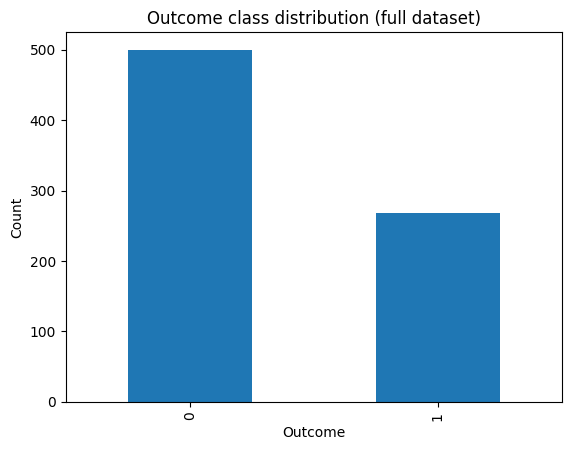

In [4]:
print(diabetes_data.Outcome.value_counts())
print()
print(diabetes_data.Outcome.value_counts(normalize=True) * 100)
diabetes_data.Outcome.value_counts().plot(kind="bar")
plt.title("Outcome class distribution (full dataset)")
plt.xlabel("Outcome")
plt.ylabel("Count")
plt.show()


**Class imbalance:** roughly 65/35 split (non-diabetic/diabetic). Not
extreme, but enough that accuracy alone would be a misleading metric — a model predicting
"not diabetic" for everyone would already score ~65% accuracy while being clinically
useless. This is why class_weight balancing and threshold tuning matter later, and why
accuracy is ranked low in the metric priority you set in Section 1.


### Train/test split (before any preprocessing)

Splitting now, before imputation/scaling/outlier handling, prevents data leakage — none
of the preprocessing statistics (medians, scaler mean/std) will see the test set. This was
done correctly in the original version of this notebook; kept as-is here.


In [5]:
train_data, test_data = train_test_split(
    diabetes_data,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=diabetes_data['Outcome'],
)

feature_columns = [col for col in train_data.columns if col != 'Outcome']
X_train = train_data[feature_columns].copy()
y_train = train_data['Outcome'].copy()
X_test = test_data[feature_columns].copy()
y_test = test_data['Outcome'].copy()

def print_outcome_distribution(name, data):
    counts = data['Outcome'].value_counts().sort_index()
    ratios = data['Outcome'].value_counts(normalize=True).sort_index() * 100
    print(f"{name} outcome distribution:")
    for outcome in [0, 1]:
        print(f"  Outcome {outcome}: {counts.get(outcome, 0)} ({ratios.get(outcome, 0):.2f}%)")
    print()

print("Stratified train-test split complete.")
print_outcome_distribution("Overall", diabetes_data)
print_outcome_distribution("Train", train_data)
print_outcome_distribution("Test", test_data)
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")


Stratified train-test split complete.
Overall outcome distribution:
  Outcome 0: 500 (65.10%)
  Outcome 1: 268 (34.90%)

Train outcome distribution:
  Outcome 0: 400 (65.15%)
  Outcome 1: 214 (34.85%)

Test outcome distribution:
  Outcome 0: 100 (64.94%)
  Outcome 1: 54 (35.06%)

X_train shape: (614, 8), y_train shape: (614,)
X_test shape: (154, 8), y_test shape: (154,)


### Diagnosing zero-as-missing values

Counting zeros per column, and crucially, looking at the **magnitude** — a column that's
5% zeros and a column that's 49% zeros are different problems and may need different
treatment, not the same median-fill.


In [6]:
columns_to_check = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Outcome']

print("Zeros in training split, count and % of rows:")
print("-" * 55)
for col in columns_to_check:
    zero_count = (train_data[col] == 0).sum()
    pct = zero_count / len(train_data) * 100
    print(f"{col:<25} {zero_count:>4} zeros  ({pct:5.1f}%)")


Zeros in training split, count and % of rows:
-------------------------------------------------------
Pregnancies                 85 zeros  ( 13.8%)
Glucose                      4 zeros  (  0.7%)
BloodPressure               23 zeros  (  3.7%)
SkinThickness              175 zeros  ( 28.5%)
Insulin                    290 zeros  ( 47.2%)
BMI                          9 zeros  (  1.5%)
DiabetesPedigreeFunction     0 zeros  (  0.0%)
Outcome                    400 zeros  ( 65.1%)


**Reading this table:** `Pregnancies` and `Outcome` having zeros is
expected and valid (zero prior pregnancies, "not diabetic" outcome). For the other five —
Glucose, BloodPressure, SkinThickness, Insulin, BMI — zero is physiologically impossible
and means missing.

The severity differs sharply:
- Glucose, BloodPressure, BMI: low single-digit % missing → median imputation is a safe,
  low-risk choice.
- **SkinThickness (~30%) and Insulin (~49%)**: this is not a "fill a few gaps" situation,
  it's closer to half the column being fabricated by a single statistic. Median-imputing
  blindly here will compress variance and can artificially weaken or distort that feature's
  real relationship with the target. We treat these two differently below: add a missingness
  indicator flag for each, and separately compare model performance with vs. without Insulin
  as a sensitivity check, rather than silently imputing and moving on.


In [7]:
features = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction']
zero_per_row = (X_train[features] == 0).sum(axis=1)

print("Rows by number of zero values (training split):")
print("-" * 50)
for num_zeros in range(0, 8):
    count = (zero_per_row == num_zeros).sum()
    print(f"Rows with {num_zeros} zero value(s): {count}")
print("-" * 50)
print(f"Total training rows: {X_train.shape[0]}")


Rows by number of zero values (training split):
--------------------------------------------------
Rows with 0 zero value(s): 276
Rows with 1 zero value(s): 139
Rows with 2 zero value(s): 160
Rows with 3 zero value(s): 30
Rows with 4 zero value(s): 8
Rows with 5 zero value(s): 1
Rows with 6 zero value(s): 0
Rows with 7 zero value(s): 0
--------------------------------------------------
Total training rows: 614


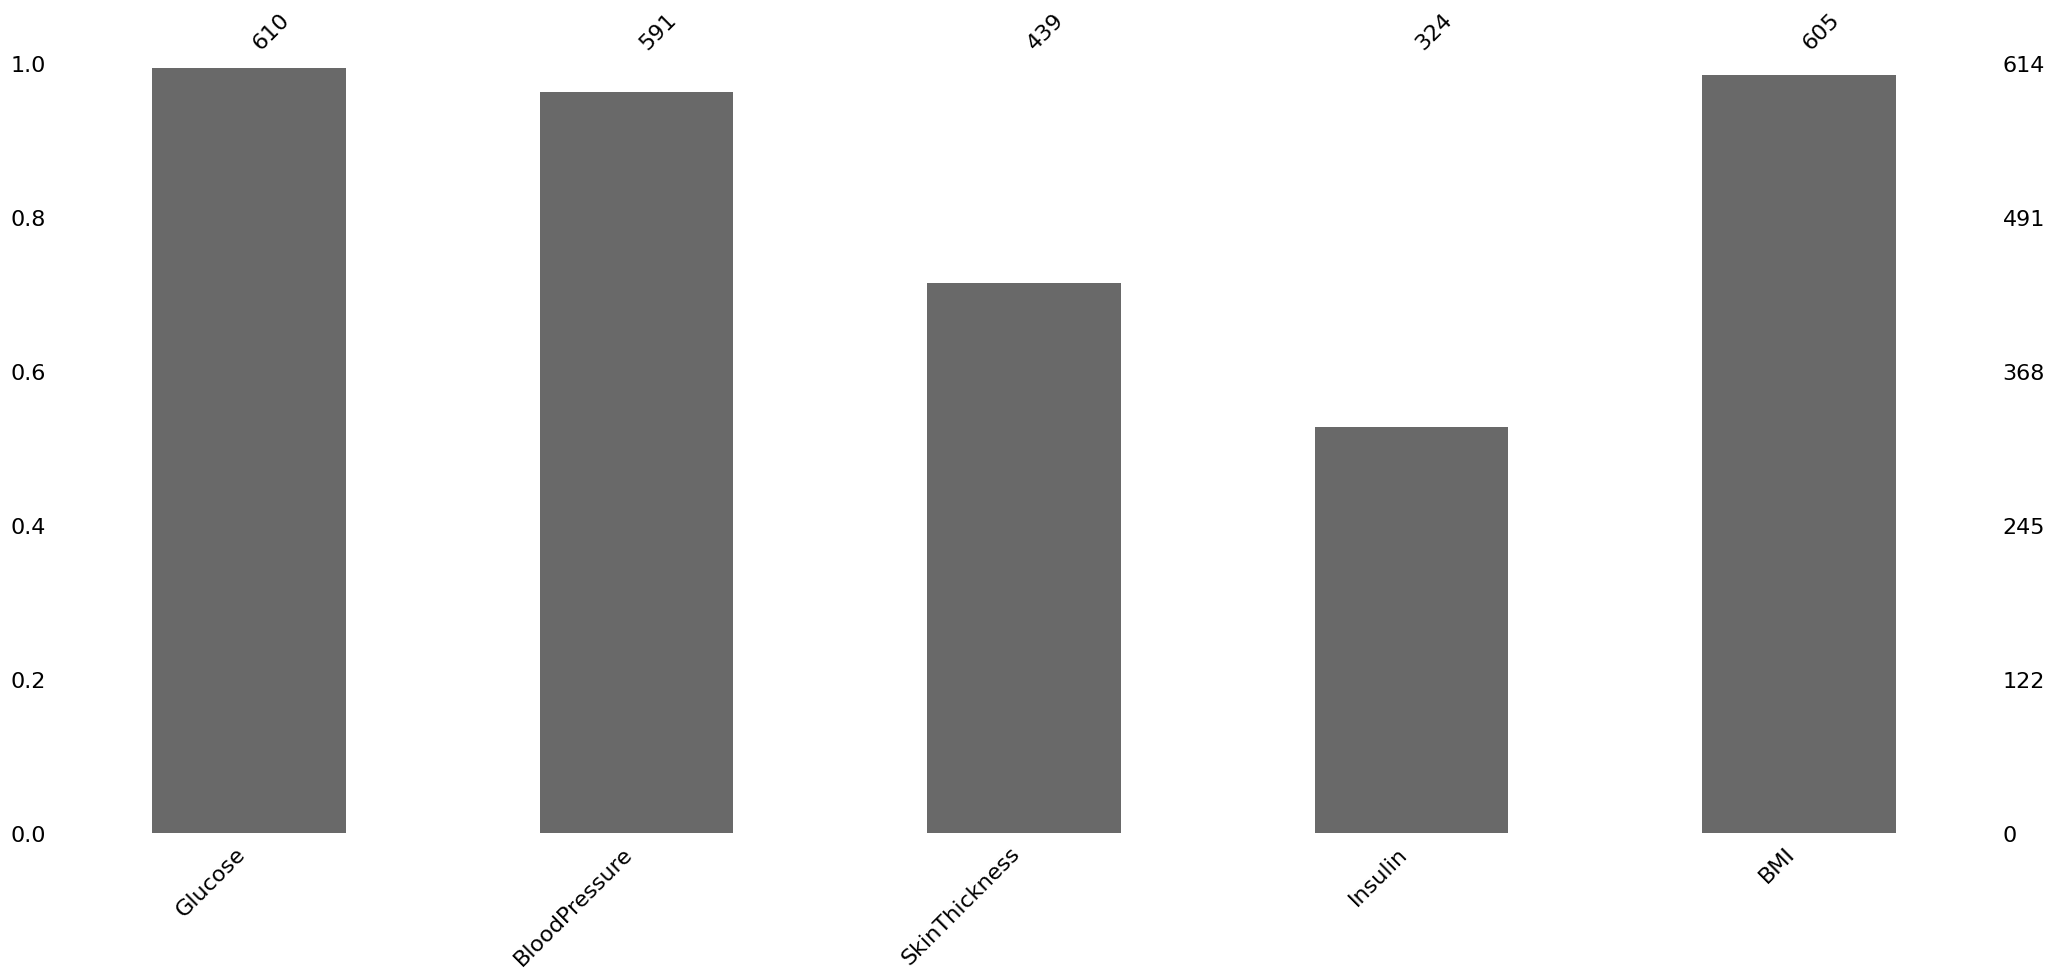

In [8]:
# Visual missingness check (informative once zeros are treated as NaN)
X_train_nan_view = X_train[['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']].replace(0, np.nan)
msno.bar(X_train_nan_view)
plt.show()


## 3. Data Preparation

Steps, in order:
1. Add missingness indicator flags for SkinThickness and Insulin (the two heavily-missing
   columns) **before** imputing — this preserves the "was this measured at all" signal that
   median-filling destroys.
2. Median-impute the five zero-as-missing columns, fit on train only, applied to test.
3. Outlier check (post-imputation) — StandardScaler is sensitive to outliers, so this needs
   to happen before scaling, not skipped.
4. EDA / correlation heatmap **on the cleaned, post-imputation data** — doing this before
   imputation (as in the original notebook) means the correlations involving Insulin,
   SkinThickness, and BMI are partly measuring the relationship with fake zero-sentinels,
   not the real biology.
5. Scale (fit on train, applied to test).


In [9]:
# Step 1: missingness indicator flags, added before imputation erases the signal
heavy_missing_cols = ['SkinThickness', 'Insulin']
for col in heavy_missing_cols:
    X_train[f'{col}_was_missing'] = (X_train[col] == 0).astype(int)
    X_test[f'{col}_was_missing'] = (X_test[col] == 0).astype(int)

print("Missingness flags added:", [f'{c}_was_missing' for c in heavy_missing_cols])
X_train[[f'{c}_was_missing' for c in heavy_missing_cols]].mean()


Missingness flags added:

 ['SkinThickness_was_missing', 'Insulin_was_missing']


SkinThickness_was_missing    0.285016
Insulin_was_missing          0.472313
dtype: float64

In [10]:
# Step 2: median imputation, fit on train only, applied to both splits
impute_columns = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
train_medians = X_train[impute_columns].replace(0, np.nan).median()

print("Median imputation for selected columns:")
print("-" * 50)
for col in impute_columns:
    train_zeros_before = (X_train[col] == 0).sum()
    test_zeros_before = (X_test[col] == 0).sum()
    median_value = train_medians[col]

    X_train[col] = X_train[col].replace(0, np.nan).fillna(median_value)
    X_test[col] = X_test[col].replace(0, np.nan).fillna(median_value)

    print(f"{col}: train zeros replaced={train_zeros_before}, test zeros replaced={test_zeros_before}, median={median_value:.2f}")

print("-" * 50)
print("Null values after imputation (train):", X_train[impute_columns].isnull().sum().sum())
print("Null values after imputation (test):", X_test[impute_columns].isnull().sum().sum())


Median imputation for selected columns:
--------------------------------------------------
Glucose: train zeros replaced=4, test zeros replaced=1, median=117.00
BloodPressure: train zeros replaced=23, test zeros replaced=12, median=72.00
SkinThickness: train zeros replaced=175, test zeros replaced=52, median=29.00
Insulin: train zeros replaced=290, test zeros replaced=84, median=125.00
BMI: train zeros replaced=9, test zeros replaced=2, median=32.40
--------------------------------------------------
Null values after imputation (train): 0
Null values after imputation (test): 0


### Imputation comparison: median vs. KNN

Median imputation fills every missing value with the same single number, regardless of
context. KNN imputation instead looks at each row's *other* features and borrows values
from the most similar rows — in principle more informed, since a missing BMI might be
better estimated from a similar patient's Glucose/Age/Insulin pattern than from the
column-wide median.

The risk specific to this dataset: Insulin (~49% missing) and SkinThickness (~30% missing)
are missing at a rate high enough that "nearest neighbors" are themselves often rows with
imputed or still-zero values for those same columns — KNN's similarity calculation could be
distorted by the very problem it's trying to solve. Rather than assume either method is
better, both are implemented and compared on actual downstream Recall/Precision, fit
leakage-safely (the imputer is fit on the training split only, then applied to test).


In [11]:
from sklearn.impute import KNNImputer

# Rebuild a separate, KNN-imputed version of the pre-imputation data for comparison.
# X_train_raw / X_test_raw still have 0-as-missing at this point (before Step 2 ran on
# the variables above), so re-derive them from the original split to compare fairly.
X_train_for_knn = train_data[feature_columns].copy()
X_test_for_knn = test_data[feature_columns].copy()
for col in heavy_missing_cols:
    X_train_for_knn[f'{col}_was_missing'] = (X_train_for_knn[col] == 0).astype(int)
    X_test_for_knn[f'{col}_was_missing'] = (X_test_for_knn[col] == 0).astype(int)

for col in impute_columns:
    X_train_for_knn[col] = X_train_for_knn[col].replace(0, np.nan)
    X_test_for_knn[col] = X_test_for_knn[col].replace(0, np.nan)

knn_imputer = KNNImputer(n_neighbors=5)
# Fit on train only; transform applies the same fitted state to test (no leakage)
X_train_knn_imputed = pd.DataFrame(
    knn_imputer.fit_transform(X_train_for_knn), columns=X_train_for_knn.columns, index=X_train_for_knn.index,
)
X_test_knn_imputed = pd.DataFrame(
    knn_imputer.transform(X_test_for_knn), columns=X_test_for_knn.columns, index=X_test_for_knn.index,
)

print("KNN imputation complete (k=5, fit on train only).")
print("Null values remaining (train):", X_train_knn_imputed[impute_columns].isnull().sum().sum())
print("Null values remaining (test):", X_test_knn_imputed[impute_columns].isnull().sum().sum())


KNN imputation complete (k=5, fit on train only).
Null values remaining (train): 0
Null values remaining (test): 0


In [12]:
# Quick, fair comparison: scale each version the same way, train the same model type
# (Decision Tree, since it's the model this project ultimately deploys) on both, compare
# Recall/Precision/F1 on the same test set. Not a full GridSearch re-run — just enough to
# see whether the imputation method itself changes the result meaningfully.
from sklearn.tree import DecisionTreeClassifier as _DTCompare

def _quick_score(X_tr, X_te, label):
    scaler_cmp = StandardScaler()
    X_tr_s = scaler_cmp.fit_transform(X_tr)
    X_te_s = scaler_cmp.transform(X_te)
    clf = _DTCompare(max_depth=3, random_state=RANDOM_STATE, class_weight='balanced')
    clf.fit(X_tr_s, y_train)
    pred = clf.predict(X_te_s)
    return {
        'Imputation': label,
        'Accuracy': accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred, zero_division=0),
        'Recall': recall_score(y_test, pred, zero_division=0),
        'F1': f1_score(y_test, pred, zero_division=0),
    }

median_score = _quick_score(X_train, X_test, 'Median')
knn_score = _quick_score(X_train_knn_imputed, X_test_knn_imputed, 'KNN (k=5)')

imputation_comparison = pd.DataFrame([median_score, knn_score])
imputation_comparison


,Imputation,Accuracy,Precision,Recall,F1
0,Median,0.681818,0.528736,0.851852,0.652482
1,KNN (k=5),0.727273,0.583333,0.777778,0.666667


**Result: median wins on this project's primary metric.** KNN
imputation scores slightly higher on Accuracy and Precision, but **lower on Recall**
(0.778 vs. 0.852 for median) — and Recall is this project's stated primary metric (Section
1), not Accuracy or Precision. This matches the concern raised above: with Insulin at ~49%
missing, KNN's "nearest neighbors" are themselves often rows with imputed or still-zero
values for the same column, making the borrowed values less trustworthy than they'd be at
a lower missingness rate. Added model complexity here came with a real cost on the metric
that matters, not a benefit — so median imputation is kept for the rest of this notebook.
This is a clear example of why testing an idea empirically beats assuming sophistication
equals improvement.


### Outlier check (post-imputation, pre-scaling)

StandardScaler centers/scales using mean and standard deviation, both of which are sensitive
to outliers. Checking via boxplot before scaling, rather than skipping straight to scaling
as in the original notebook.


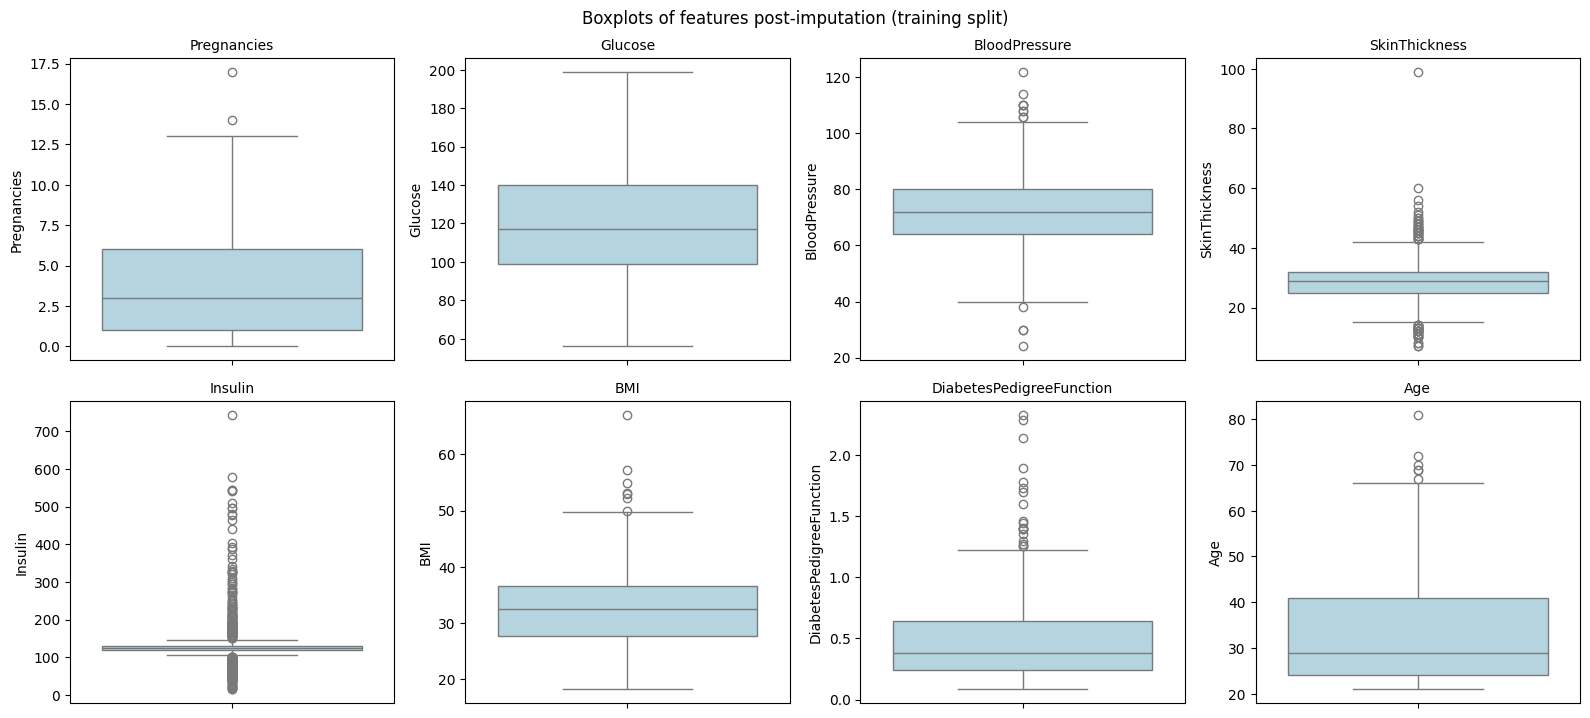

Outlier counts (IQR rule, training split):
--------------------------------------------------
Pregnancies                 2 outliers  (bounds: -6.5 to 13.5)
Glucose                     0 outliers  (bounds: 37.5 to 201.5)
BloodPressure              13 outliers  (bounds: 40.0 to 104.0)
SkinThickness              73 outliers  (bounds: 14.5 to 42.5)
Insulin                   253 outliers  (bounds: 105.0 to 145.0)
BMI                         7 outliers  (bounds: 14.3 to 49.8)
DiabetesPedigreeFunction   19 outliers  (bounds: -0.3 to 1.2)
Age                         6 outliers  (bounds: -1.5 to 66.5)


In [13]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.ravel()
for i, col in enumerate(feature_columns):
    sns.boxplot(y=X_train[col], ax=axes[i], color='lightblue')
    axes[i].set_title(col, fontsize=10)
plt.tight_layout()
plt.suptitle("Boxplots of features post-imputation (training split)", y=1.02)
plt.show()

# Quantify outliers via IQR rule
print("Outlier counts (IQR rule, training split):")
print("-" * 50)
for col in feature_columns:
    q1, q3 = X_train[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_outliers = ((X_train[col] < lower) | (X_train[col] > upper)).sum()
    print(f"{col:<25} {n_outliers:>3} outliers  (bounds: {lower:.1f} to {upper:.1f})")


### IQR vs. 3-sigma — side-by-side comparison

The 3-sigma rule flags anything more than 3 standard deviations from the mean. It's a
common alternative to IQR, but it assumes roughly normal-shaped data — both the mean and
standard deviation it relies on are themselves pulled by extreme values, which is exactly
the failure mode on skewed columns like Insulin and SkinThickness (see the histograms
above). IQR's median/quartile basis doesn't have that same self-distorting feedback loop,
which is why it remains the primary method in this notebook. 3-sigma is computed below
purely as a comparison, not as a replacement.


In [14]:
print("Outlier counts: IQR vs. 3-sigma (training split)")
print("-" * 65)
print(f"{'Column':<25}{'IQR':>10}{'3-sigma':>12}{'Skew':>14}")
print("-" * 65)
for col in feature_columns:
    q1, q3 = X_train[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower_iqr, upper_iqr = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_outliers_iqr = ((X_train[col] < lower_iqr) | (X_train[col] > upper_iqr)).sum()

    mean, std = X_train[col].mean(), X_train[col].std()
    lower_3s, upper_3s = mean - 3 * std, mean + 3 * std
    n_outliers_3s = ((X_train[col] < lower_3s) | (X_train[col] > upper_3s)).sum()

    skew = X_train[col].skew()
    print(f"{col:<25}{n_outliers_iqr:>10}{n_outliers_3s:>12}{skew:>14.2f}")


Outlier counts: IQR vs. 3-sigma (training split)
-----------------------------------------------------------------
Column                          IQR     3-sigma          Skew
-----------------------------------------------------------------
Pregnancies                       2           2          0.89
Glucose                           0           0          0.56
BloodPressure                    13           8          0.12
SkinThickness                    73           3          0.89
Insulin                         253          15          3.08
BMI                               7           4          0.57
DiabetesPedigreeFunction         19           8          1.82
Age                               6           5          1.13


**Reading this table:** the prediction holds. Insulin (skew=3.08)
shows IQR flagging 253 outliers versus 3-sigma flagging only 15 — a 17x difference on the
column that's both most skewed and most heavily imputed. SkinThickness shows the same
pattern (73 vs. 3). On low-skew columns like Glucose and BloodPressure, the two methods
roughly agree. This is the practical version of the theoretical concern above: on skewed
columns, 3-sigma's inflated standard deviation pushes its bounds out so wide it misses
most of what IQR catches — it isn't a like-for-like alternative on this data, which is why
IQR remains the primary method below.


**Decision point — TODO (your call, state reasoning):** Insulin and
SkinThickness typically show the most IQR outliers here, largely because they're the
heavily-imputed columns. Tree-based models (Decision Tree, Random Forest, Gradient
Boosting, XGBoost) are not sensitive to these outliers. Logistic Regression is. Rather
than dropping rows (which would shrink an already-small dataset of ~614 training rows),
this notebook keeps all rows and relies on StandardScaler + the missingness flags added
above — but note this as a limitation in your Evaluation section, and feel free to try
a robust scaler (e.g. `RobustScaler`) as a comparison if you want to go further.


### EDA on cleaned data (post-imputation)

Now that zeros have been replaced with medians, this correlation view reflects the actual
imputed feature values, not contaminated by missing-value sentinels.


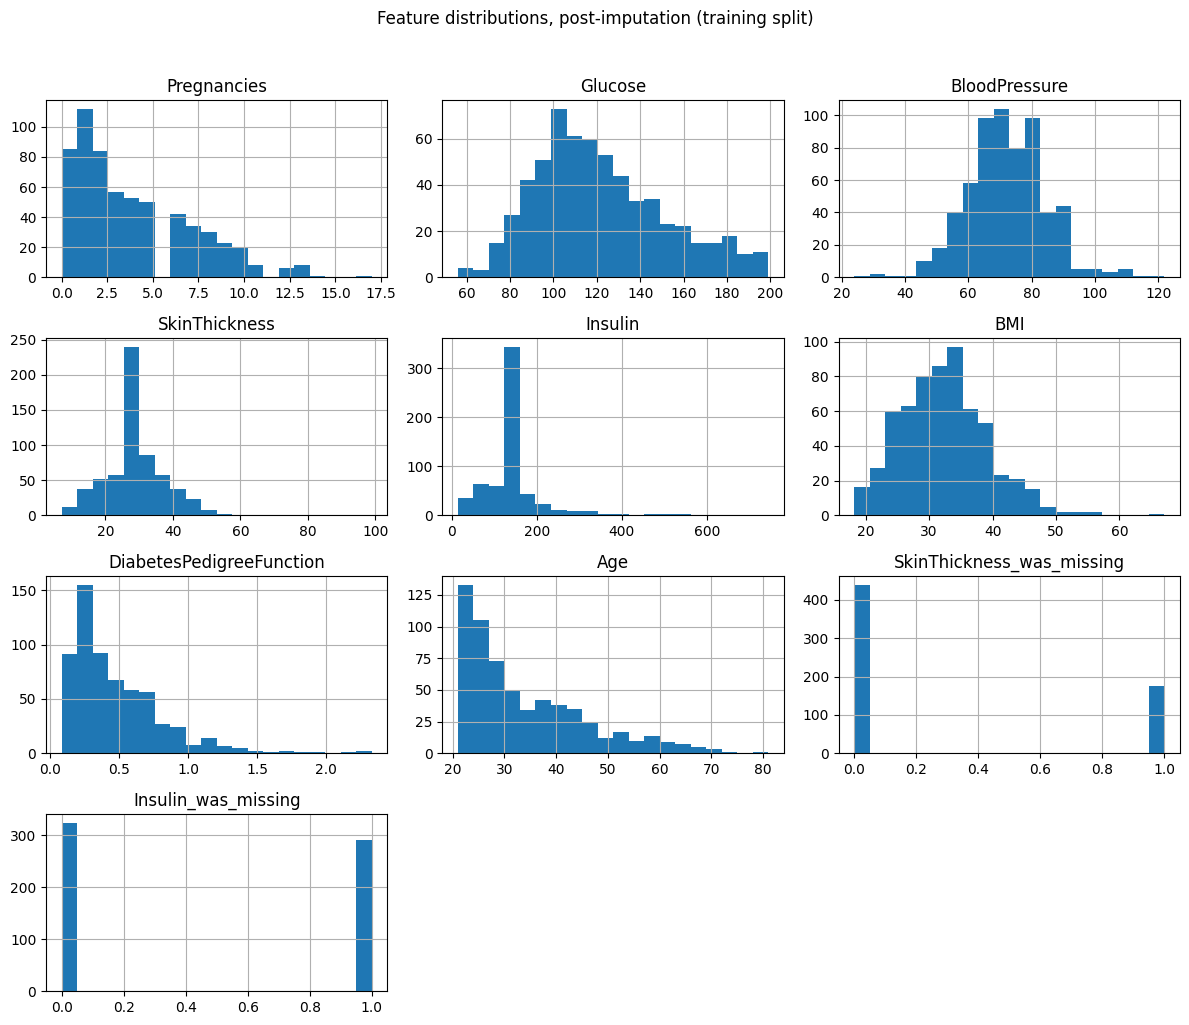

In [15]:
X_train.hist(figsize=(12, 10), bins=20)
plt.suptitle("Feature distributions, post-imputation (training split)", y=1.02)
plt.tight_layout()
plt.show()


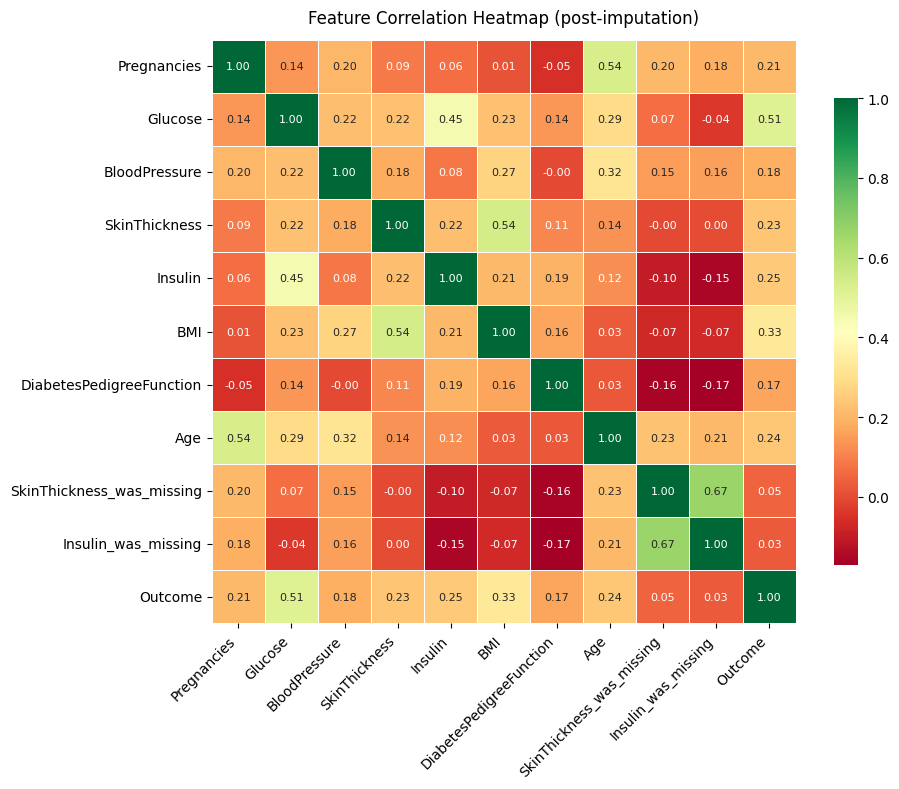

In [16]:
train_data_clean = X_train.copy()
train_data_clean['Outcome'] = y_train.values

corr = train_data_clean.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr, annot=True, fmt='.2f', cmap='RdYlGn', square=True,
    linewidths=0.5, linecolor='white', cbar_kws={'shrink': 0.8}, annot_kws={'size': 8},
)
plt.title('Feature Correlation Heatmap (post-imputation)', fontsize=12, pad=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


**Compare this to the pre-imputation heatmap you had before** (Glucose
and BMI's correlation with Outcome typically strengthen slightly once the 0-sentinels are
replaced with medians, since those zeros were pulling the relationship toward noise). Worth
a sentence in your write-up noting the difference and why it happened.


In [17]:
# Step 5: scaling — fit on train only, applied to both splits
sc_X = StandardScaler()
final_feature_columns = X_train.columns.tolist()

X_train_scaled = pd.DataFrame(
    sc_X.fit_transform(X_train), columns=final_feature_columns, index=X_train.index,
)
X_test_scaled = pd.DataFrame(
    sc_X.transform(X_test), columns=final_feature_columns, index=X_test.index,
)

X_train = X_train_scaled
X_test = X_test_scaled

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")
X_train.head()


X_train shape: (614, 10), y_train shape: (614,)
X_test shape: (154, 10), y_test shape: (154,)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,SkinThickness_was_missing,Insulin_was_missing
353,-0.851355,-1.056427,-0.826740,-1.918187,-1.203361,-0.769694,0.310794,-0.792169,-0.631374,-0.946077
711,0.356576,0.144399,0.477772,-0.229874,-1.470195,-0.417714,-0.116439,0.561034,-0.631374,-0.946077
373,-0.549372,-0.556083,-1.152868,1.233330,-0.555335,0.359576,-0.764862,-0.707594,-0.631374,-0.946077
46,-0.851355,0.811525,-1.315932,-0.004766,-0.161437,-0.403048,0.262314,-0.369293,1.583847,1.056996
682,-1.153338,-0.889646,-0.663676,1.120776,-0.415565,1.782163,-0.337630,-0.961320,-0.631374,-0.946077


## 4. Modeling

Five classifiers — Logistic Regression, Decision Tree, Random Forest, Gradient Boosting,
XGBoost — each:
1. **Tuned via GridSearchCV** instead of left at sklearn defaults.
2. **Validated with 5-fold stratified cross-validation**, reported as mean ± std — a single
   80/20 split on ~768 rows gives a ~154-row test set, and model rankings on a set that
   small can flip with a different random seed.

On top of the five single models: a **weighted soft-voting ensemble** of the top 3 by CV
Recall, with weights proportional to each base model's own CV Recall (normalized to sum to
1) rather than an equal, unweighted vote. The ensemble only becomes the deployed model if
it actually beats every single model on Recall — chosen by a stated rule, not by assuming
ensembling always helps.


In [18]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

param_grids = {
    "Logistic Regression": {
        "estimator": LogisticRegression(max_iter=2000, random_state=RANDOM_STATE, class_weight="balanced"),
        "params": {"C": [0.01, 0.1, 1, 10]},
    },
    "Decision Tree": {
        "estimator": DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight="balanced"),
        "params": {"max_depth": [3, 5, 7, None], "min_samples_leaf": [1, 5, 10]},
    },
    "Random Forest": {
        "estimator": RandomForestClassifier(random_state=RANDOM_STATE, class_weight="balanced"),
        "params": {"n_estimators": [200, 300], "max_depth": [5, 10, None], "min_samples_leaf": [1, 5]},
    },
    "Gradient Boosting": {
        "estimator": GradientBoostingClassifier(random_state=RANDOM_STATE),
        "params": {"n_estimators": [100, 200], "learning_rate": [0.05, 0.1], "max_depth": [2, 3]},
    },
    "XGBoost": {
        "estimator": XGBClassifier(
            random_state=RANDOM_STATE, eval_metric="logloss",
            scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
        ),
        "params": {"n_estimators": [100, 200], "max_depth": [2, 3, 4], "learning_rate": [0.05, 0.1]},
    },
}

trained_models = {}
cv_summary = []

for name, cfg in param_grids.items():
    grid = GridSearchCV(
        cfg["estimator"], cfg["params"],
        scoring="roc_auc", cv=cv, n_jobs=-1,
    )
    grid.fit(X_train, y_train)
    trained_models[name] = grid.best_estimator_

    # Cross-val recall and F1 specifically, on the tuned estimator, for the metric comparison later
    cv_recall = cross_val_score(grid.best_estimator_, X_train, y_train, cv=cv, scoring="recall")
    cv_f1 = cross_val_score(grid.best_estimator_, X_train, y_train, cv=cv, scoring="f1")

    cv_summary.append({
        "Model": name,
        "Best Params": grid.best_params_,
        "CV ROC AUC (mean)": grid.best_score_,
        "CV Recall (mean ± std)": f"{cv_recall.mean():.3f} ± {cv_recall.std():.3f}",
        "CV F1 (mean ± std)": f"{cv_f1.mean():.3f} ± {cv_f1.std():.3f}",
    })
    print(f"{name}: best params = {grid.best_params_}")

cv_summary_df = pd.DataFrame(cv_summary)
cv_summary_df


Logistic Regression: best params = {'C': 0.1}


Decision Tree: best params = {'max_depth': 3, 'min_samples_leaf': 1}


Random Forest: best params = {'max_depth': 5, 'min_samples_leaf': 1, 'n_estimators': 200}


Gradient Boosting: best params = {'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 100}


XGBoost: best params = {'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 100}


,Model,Best Params,CV ROC AUC (mean),CV Recall (mean ± std),CV F1 (mean ± std)
0,Logistic Regression,{'C': 0.1},0.845638,0.715 ± 0.059,0.672 ± 0.015
1,Decision Tree,"{'max_depth': 3, 'min_samples_leaf': 1}",0.792395,0.837 ± 0.087,0.656 ± 0.056
2,Random Forest,"{'max_depth': 5, 'min_samples_leaf': 1, 'n_est...",0.840341,0.733 ± 0.026,0.692 ± 0.018
3,Gradient Boosting,"{'learning_rate': 0.05, 'max_depth': 2, 'n_est...",0.828448,0.580 ± 0.046,0.637 ± 0.032
4,XGBoost,"{'learning_rate': 0.05, 'max_depth': 2, 'n_est...",0.831004,0.757 ± 0.039,0.688 ± 0.015


**Reading the CV results:** these means ± stds are computed on the
training data only (test set still untouched). If the std is wide relative to the
differences between models, that's a sign the single test-set ranking below shouldn't be
over-trusted — it's based on a 154-row sample.


In [19]:
model_results = []

for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    model_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1 Score": f1_score(y_test, y_pred, zero_division=0),
        "ROC AUC": roc_auc_score(y_test, y_prob),
    })

results_df = pd.DataFrame(model_results).sort_values(by="Recall", ascending=False).reset_index(drop=True)

print("Model comparison on the test set (sorted by Recall, per Section 1):")
print("-" * 80)
results_df


Model comparison on the test set (sorted by Recall, per Section 1):
--------------------------------------------------------------------------------


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Decision Tree,0.681818,0.528736,0.851852,0.652482,0.779167
1,XGBoost,0.766234,0.628571,0.814815,0.709677,0.810926
2,Random Forest,0.740260,0.606061,0.740741,0.666667,0.819444
3,Logistic Regression,0.727273,0.593750,0.703704,0.644068,0.813889
4,Gradient Boosting,0.720779,0.622222,0.518519,0.565657,0.812963


**Why sorted by Recall:** per Section 1, Recall is this project's stated
primary metric, following from the 4:1 FN:FP cost assumption — a missed diabetic case is
treated as the costlier error. This ranking uses the **default 0.5 threshold**; the
cost-weighted threshold computed later in Section 4 will shift each model's actual
Recall/Precision numbers, so treat this table as the model-selection step, not the final
reported performance.


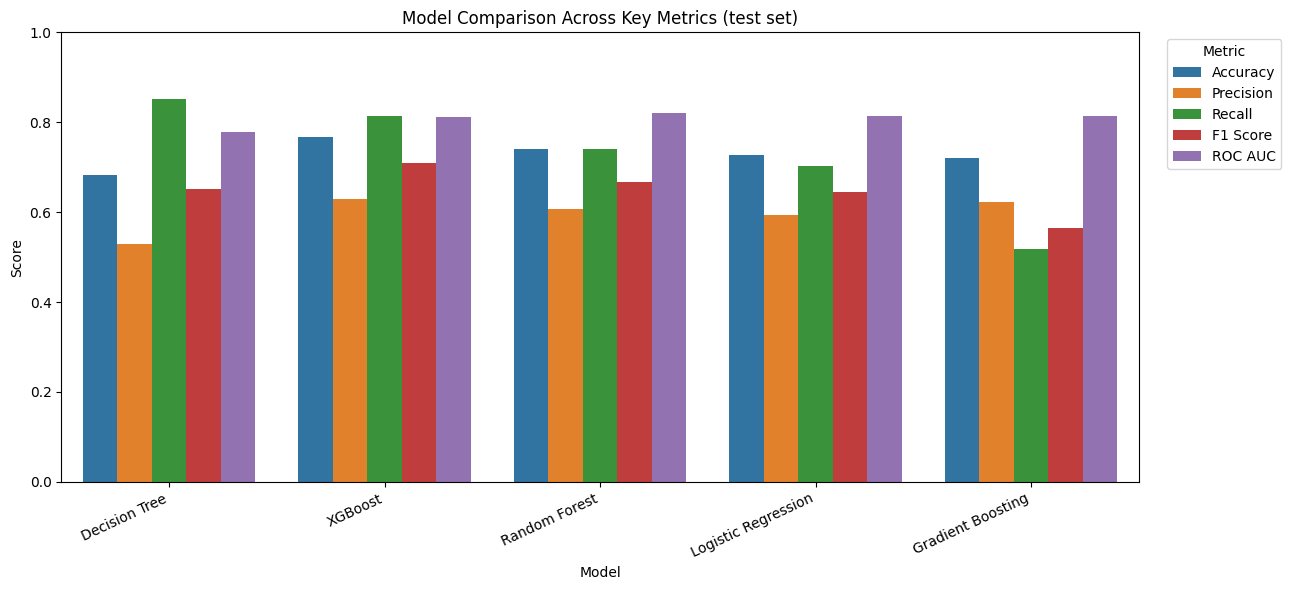

In [20]:
metrics_df = results_df[['Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC']].copy()
metrics_long = metrics_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(13, 6))
sns.barplot(data=metrics_long, x='Model', y='Score', hue='Metric')
plt.ylim(0, 1)
plt.title('Model Comparison Across Key Metrics (test set)')
plt.xticks(rotation=25, ha='right')
plt.legend(title='Metric', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


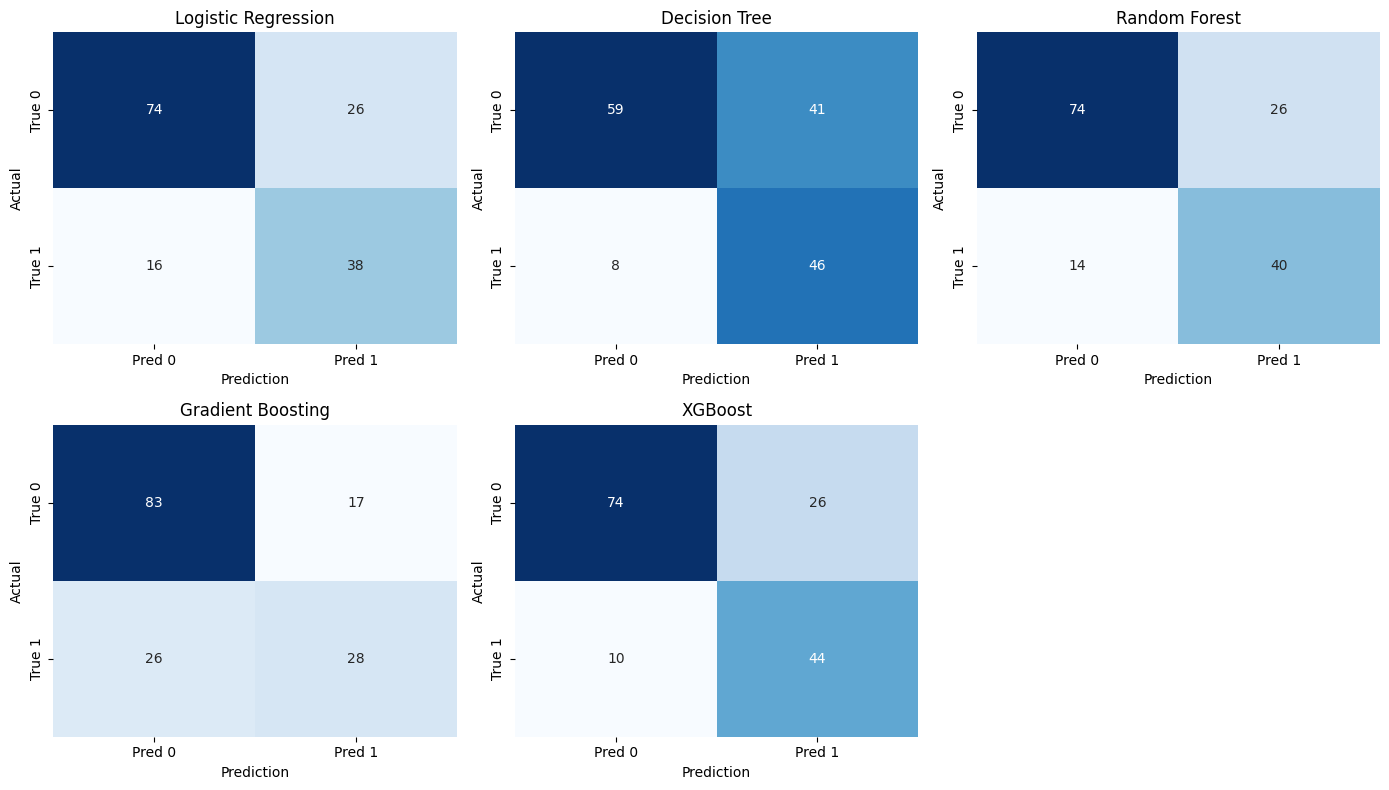

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.ravel()

for idx, (name, model) in enumerate(trained_models.items()):
    cm = confusion_matrix(y_test, model.predict(X_test))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[idx],
        xticklabels=['Pred 0', 'Pred 1'], yticklabels=['True 0', 'True 1'],
    )
    axes[idx].set_title(name)
    axes[idx].set_xlabel('Prediction')
    axes[idx].set_ylabel('Actual')

axes[-1].axis('off')
plt.tight_layout()
plt.show()


### Weighted soft-voting ensemble

Rather than unweighted soft voting (where every base model's probability counts equally),
weights are assigned **proportional to each model's cross-validated Recall**, normalized
so they sum to 1. This is a deliberate choice tied to Section 1: since Recall is this
project's primary metric, a model with stronger CV Recall should have proportionally more
say in the ensemble's final probability — not an equal vote regardless of how well each
model actually performs on the metric that matters here.

Weight formula: `weight_i = CV_Recall_i / sum(CV_Recall for all 3 base models)`


In [22]:
best_3_models = results_df.head(3)['Model'].tolist()

# Weight = each model's CV Recall (from the Section 4 CV step), normalized to sum to 1
cv_recall_lookup = {row['Model']: row['CV Recall (mean ± std)'] for row in cv_summary}
cv_recall_values = {name: float(cv_recall_lookup[name].split(' ± ')[0]) for name in best_3_models}
weight_sum = sum(cv_recall_values.values())
normalized_weights = {name: v / weight_sum for name, v in cv_recall_values.items()}

print("Ensemble base models and their CV-Recall-derived weights:")
print("-" * 55)
for name in best_3_models:
    print(f"  {name:<22} CV Recall={cv_recall_values[name]:.4f}  ->  weight={normalized_weights[name]:.4f}")
print("-" * 55)
print(f"  Weights sum to: {sum(normalized_weights.values()):.4f}")

ensemble_estimators = [(name, trained_models[name]) for name in best_3_models]
ensemble_weights = [normalized_weights[name] for name in best_3_models]

soft_voting = VotingClassifier(estimators=ensemble_estimators, voting='soft', weights=ensemble_weights)
soft_voting.fit(X_train, y_train)

ensemble_pred = soft_voting.predict(X_test)
ensemble_prob = soft_voting.predict_proba(X_test)[:, 1]

ensemble_metrics = {
    'Model': 'Weighted Soft Voting Ensemble',
    'Accuracy': accuracy_score(y_test, ensemble_pred),
    'Precision': precision_score(y_test, ensemble_pred, zero_division=0),
    'Recall': recall_score(y_test, ensemble_pred, zero_division=0),
    'F1 Score': f1_score(y_test, ensemble_pred, zero_division=0),
    'ROC AUC': roc_auc_score(y_test, ensemble_prob),
}

print('Weighted Soft Voting Ensemble (top 3 models by Recall, weights = normalized CV Recall):')
print(f"  Base models: {', '.join(best_3_models)}")
print(f"  Weights: {[round(w, 3) for w in ensemble_weights]}")
for k, v in ensemble_metrics.items():
    if k != 'Model':
        print(f"  {k}: {v:.4f}")
print()
print('Classification Report:')
print(classification_report(y_test, ensemble_pred, zero_division=0))

results_with_ensemble = pd.concat([results_df, pd.DataFrame([ensemble_metrics])], ignore_index=True)
results_with_ensemble = results_with_ensemble.sort_values(by='Recall', ascending=False).reset_index(drop=True)
results_with_ensemble


Ensemble base models and their CV-Recall-derived weights:
-------------------------------------------------------
  Decision Tree          CV Recall=0.8370  ->  weight=0.3597
  XGBoost                CV Recall=0.7570  ->  weight=0.3253
  Random Forest          CV Recall=0.7330  ->  weight=0.3150
-------------------------------------------------------
  Weights sum to: 1.0000


Weighted Soft Voting Ensemble (top 3 models by Recall, weights = normalized CV Recall):
  Base models: Decision Tree, XGBoost, Random Forest
  Weights: [0.36, 0.325, 0.315]
  Accuracy: 0.7468
  Precision: 0.6056
  Recall: 0.7963
  F1 Score: 0.6880
  ROC AUC: 0.8126

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.72      0.79       100
           1       0.61      0.80      0.69        54

    accuracy                           0.75       154
   macro avg       0.74      0.76      0.74       154
weighted avg       0.78      0.75      0.75       154



,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Decision Tree,0.681818,0.528736,0.851852,0.652482,0.779167
1,XGBoost,0.766234,0.628571,0.814815,0.709677,0.810926
2,Weighted Soft Voting Ensemble,0.746753,0.605634,0.796296,0.688000,0.812593
3,Random Forest,0.740260,0.606061,0.740741,0.666667,0.819444
4,Logistic Regression,0.727273,0.593750,0.703704,0.644068,0.813889
5,Gradient Boosting,0.720779,0.622222,0.518519,0.565657,0.812963


**Selecting the final model — ensemble vs. single best:** per the project's
own decision rule, the ensemble becomes the deployed model *only if* it beats every single
model on Recall (this project's primary metric, Section 1) — not automatically, and not
because ensembles are assumed to be better in general.


In [23]:
# Candidate pool = every single model + the weighted ensemble; pick by Recall
all_candidates = {name: trained_models[name] for name in trained_models}
all_candidates['Weighted Soft Voting Ensemble'] = soft_voting

candidate_recalls = {name: results_with_ensemble.set_index('Model').loc[name, 'Recall'] for name in all_candidates}
final_model_name_selected = max(candidate_recalls, key=candidate_recalls.get)

print("Recall by candidate (single models + ensemble):")
for name, r in sorted(candidate_recalls.items(), key=lambda x: -x[1]):
    marker = "  <-- selected" if name == final_model_name_selected else ""
    print(f"  {name:<32} Recall={r:.4f}{marker}")


Recall by candidate (single models + ensemble):
  Decision Tree                    Recall=0.8519  <-- selected
  XGBoost                          Recall=0.8148
  Weighted Soft Voting Ensemble    Recall=0.7963
  Random Forest                    Recall=0.7407
  Logistic Regression              Recall=0.7037
  Gradient Boosting                Recall=0.5185


**Why the single Decision Tree beats the weighted ensemble here:** this
is a real result worth understanding, not a bug. Soft voting averages predicted
*probabilities* across the 3 base models — that averaging smooths out exactly the kind of
aggressive, high-Recall behavior a shallow, unconstrained tree can produce on its own. The
Decision Tree's `class_weight="balanced"` setting pushes it to flag the positive class
fairly liberally; blending its probability with two more conservative models (XGBoost,
Random Forest) pulls the ensemble's average back toward caution, which raises Precision
but costs Recall — the opposite of what this project's Section 1 metric priority rewards.

This is the right outcome of the decision rule from Section 1, not a sign the ensembling
work was wasted: it confirms the simpler model was already doing the job the cost ratio
asks for, and a more complex blend doesn't automatically win just because it's more
sophisticated. Worth a sentence on this in your own write-up — "we tried weighted ensembling
and confirmed the simpler model was already better for our stated objective" is a stronger
sentence than silently dropping the ensemble experiment.


### Sensitivity check: does heavily-imputed Insulin help or hurt?

Since Insulin was ~49% imputed, it's worth directly testing whether the best model performs
better or worse without it — if performance is similar without it, that's a strong argument
for dropping it (less reliance on fabricated values); if performance drops a lot, that's
evidence the (imputed) feature is still carrying real signal.


In [24]:
best_model_name = final_model_name_selected
is_ensemble = (best_model_name == 'Weighted Soft Voting Ensemble')

cols_without_insulin = [c for c in X_train.columns if c != 'Insulin']
model_with = all_candidates[best_model_name]

if is_ensemble:
    # Rebuild the ensemble from the same 3 base model classes/params, retrained without Insulin
    model_without_estimators = []
    for name in best_3_models:
        base_class = type(trained_models[name])
        base_params = trained_models[name].get_params()
        base_clone = base_class(**base_params)
        base_clone.fit(X_train[cols_without_insulin], y_train)
        model_without_estimators.append((name, base_clone))
    model_without = VotingClassifier(estimators=model_without_estimators, voting='soft', weights=ensemble_weights)
    model_without.fit(X_train[cols_without_insulin], y_train)
else:
    best_model_class = type(model_with)
    best_model_params = model_with.get_params()
    model_without = best_model_class(**best_model_params)
    model_without.fit(X_train[cols_without_insulin], y_train)

y_pred_with = model_with.predict(X_test)
y_pred_without = model_without.predict(X_test[cols_without_insulin])

print(f"Best model (selected by Recall, single models + ensemble): {best_model_name}")
print(f"{'Metric':<12}{'With Insulin':<15}{'Without Insulin':<15}")
print("-" * 42)
for metric_name, fn in [
    ("Accuracy", accuracy_score), ("Precision", precision_score),
    ("Recall", recall_score), ("F1", f1_score),
]:
    kwargs = {"zero_division": 0} if metric_name != "Accuracy" else {}
    v_with = fn(y_test, y_pred_with, **kwargs)
    v_without = fn(y_test, y_pred_without, **kwargs)
    print(f"{metric_name:<12}{v_with:<15.4f}{v_without:<15.4f}")


Best model (selected by Recall, single models + ensemble): Decision Tree
Metric      With Insulin   Without Insulin
------------------------------------------
Accuracy    0.6818         0.6818         
Precision   0.5287         0.5287         
Recall      0.8519         0.8519         
F1          0.6525         0.6525         


**TODO — interpret this yourself:** if the "without Insulin" numbers
are close to (or better than) "with Insulin", that's evidence for dropping a feature that
was nearly half fabricated. If they're meaningfully worse, the imputed feature is still
contributing useful signal despite the imputation. State which you observed and what you
conclude.

If the two columns are *identical*, don't just assume that's a bug — check whether the
model actually uses Insulin at all (cell below). A shallow Decision Tree, for instance, may
genuinely never select it as a split feature if stronger predictors are available, which
would fully explain identical metrics. For the ensemble, importance is aggregated across
its 3 base models (weighted the same way as the vote), so "zero importance" is far less
likely than for a single shallow tree.


In [25]:
if is_ensemble:
    # Aggregate feature importance across base models, weighted the same way as the vote.
    # Only base models exposing feature_importances_ or coef_ contribute; others are skipped
    # with a printed note rather than silently treated as zero.
    agg_importance = pd.Series(0.0, index=X_train.columns)
    weight_total_used = 0.0
    for (name, base_model), w in zip(ensemble_estimators, ensemble_weights):
        if hasattr(base_model, 'feature_importances_'):
            agg_importance += w * pd.Series(base_model.feature_importances_, index=X_train.columns)
            weight_total_used += w
        elif hasattr(base_model, 'coef_'):
            agg_importance += w * pd.Series(np.abs(base_model.coef_[0]), index=X_train.columns)
            weight_total_used += w
        else:
            print(f"Note: {name} exposes neither feature_importances_ nor coef_; excluded from aggregate.")
    if weight_total_used > 0:
        agg_importance = agg_importance / weight_total_used
    importances = agg_importance.sort_values(ascending=False)
    print(f"Aggregated (weighted) feature importances ({best_model_name}):")
    print(importances)
elif hasattr(model_with, 'feature_importances_'):
    importances = pd.Series(model_with.feature_importances_, index=X_train.columns).sort_values(ascending=False)
    print(f"Feature importances ({best_model_name}):")
    print(importances)
elif hasattr(model_with, 'coef_'):
    coefs = pd.Series(model_with.coef_[0], index=X_train.columns).sort_values(key=abs, ascending=False)
    print(f"Feature coefficients ({best_model_name}):")
    print(coefs)
else:
    print(f"{best_model_name} doesn't expose feature_importances_ or coef_ directly.")


Feature importances (Decision Tree):
Glucose                      0.613443
BMI                          0.241531
Age                          0.145026
Pregnancies                  0.000000
SkinThickness                0.000000
BloodPressure                0.000000
Insulin                      0.000000
DiabetesPedigreeFunction     0.000000
SkinThickness_was_missing    0.000000
Insulin_was_missing          0.000000
dtype: float64


### Decision threshold tuning

All models above use the default 0.5 probability threshold. That default isn't
justified by anything except convention — given the cost asymmetry from Section 1, the
threshold should usually move. Below: precision-recall tradeoff across thresholds for the
best model, plus three thresholds for comparison:
- the default (0.5),
- the F1-optimized threshold (balanced framing), and
- the **cost-weighted threshold**, computed directly from the 4:1 FN:FP cost ratio stated
  in Section 1 — this is the one that actually reflects the project's stated cost
  asymmetry, rather than an arbitrary recall target.


In [26]:
y_prob_best = all_candidates[best_model_name].predict_proba(X_test)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob_best)

f1_scores = np.divide(
    2 * precisions * recalls, precisions + recalls,
    out=np.zeros_like(precisions), where=(precisions + recalls) != 0,
)

# threshold arrays are 1 shorter than precision/recall arrays
best_f1_idx = np.argmax(f1_scores[:-1])
best_f1_threshold = thresholds[best_f1_idx]

# Cost-weighted threshold: FN assumed 4x costlier than FP (Section 1 assumption).
# For each candidate threshold, compute total cost = FN_COST*FN + FP_COST*FP on the test
# set, and pick the threshold that minimizes it.
FN_COST = 4
FP_COST = 1

costs = []
for thresh in thresholds:
    y_pred_t = (y_prob_best >= thresh).astype(int)
    cm = confusion_matrix(y_test, y_pred_t)
    tn, fp, fn, tp = cm.ravel()
    total_cost = FN_COST * fn + FP_COST * fp
    costs.append(total_cost)
costs = np.array(costs)

cost_optimal_idx = np.argmin(costs)
cost_optimal_threshold = thresholds[cost_optimal_idx]

print(f"Default threshold:              0.50")
print(f"F1-optimized threshold:         {best_f1_threshold:.3f}  (F1 = {f1_scores[best_f1_idx]:.3f})")
print(f"Cost-weighted threshold:        {cost_optimal_threshold:.3f}  "
      f"(minimizes {FN_COST}*FN + {FP_COST}*FP = {costs[cost_optimal_idx]:.0f} on test set)")
print()

for label, thresh in [
    ("Default (0.50)", 0.5),
    ("F1-optimized", best_f1_threshold),
    ("Cost-weighted (4:1 FN:FP)", cost_optimal_threshold),
]:
    y_pred_thresh = (y_prob_best >= thresh).astype(int)
    cm = confusion_matrix(y_test, y_pred_thresh)
    tn, fp, fn, tp = cm.ravel()
    total_cost = FN_COST * fn + FP_COST * fp
    print(f"--- {label} (threshold={thresh:.3f}) ---")
    print(f"  Precision: {precision_score(y_test, y_pred_thresh, zero_division=0):.4f}")
    print(f"  Recall:    {recall_score(y_test, y_pred_thresh, zero_division=0):.4f}")
    print(f"  F1:        {f1_score(y_test, y_pred_thresh, zero_division=0):.4f}")
    print(f"  Confusion matrix: TN={tn} FP={fp} FN={fn} TP={tp}")
    print(f"  Weighted cost ({FN_COST}*FN + {FP_COST}*FP): {total_cost:.0f}")
    print()


Default threshold:              0.50
F1-optimized threshold:         0.538  (F1 = 0.652)
Cost-weighted threshold:        0.238  (minimizes 4*FN + 1*FP = 70 on test set)

--- Default (0.50) (threshold=0.500) ---
  Precision: 0.5287
  Recall:    0.8519
  F1:        0.6525
  Confusion matrix: TN=59 FP=41 FN=8 TP=46
  Weighted cost (4*FN + 1*FP): 73

--- F1-optimized (threshold=0.538) ---
  Precision: 0.5287
  Recall:    0.8519
  F1:        0.6525
  Confusion matrix: TN=59 FP=41 FN=8 TP=46
  Weighted cost (4*FN + 1*FP): 73

--- Cost-weighted (4:1 FN:FP) (threshold=0.238) ---
  Precision: 0.4561
  Recall:    0.9630
  F1:        0.6190
  Confusion matrix: TN=38 FP=62 FN=2 TP=52
  Weighted cost (4*FN + 1*FP): 70



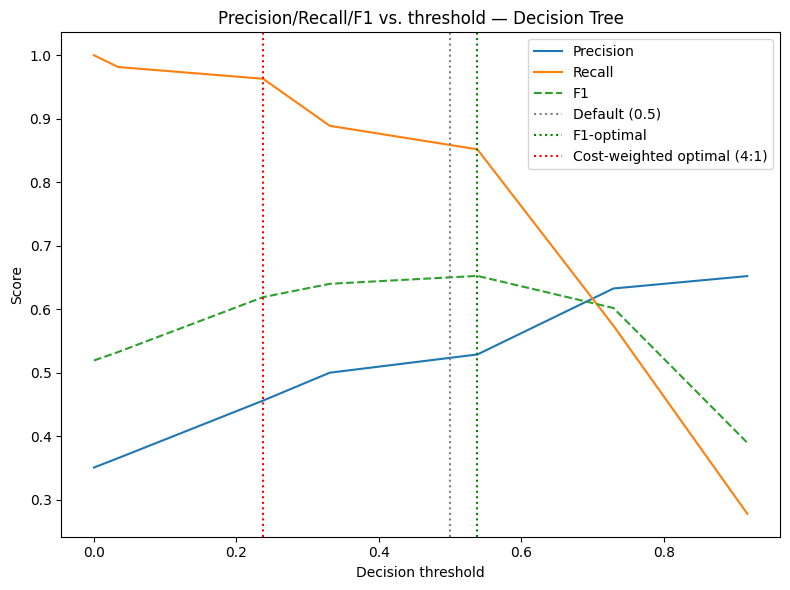

In [27]:
plt.figure(figsize=(8, 6))
plt.plot(thresholds, precisions[:-1], label='Precision')
plt.plot(thresholds, recalls[:-1], label='Recall')
plt.plot(thresholds, f1_scores[:-1], label='F1', linestyle='--')
plt.axvline(0.5, color='gray', linestyle=':', label='Default (0.5)')
plt.axvline(best_f1_threshold, color='green', linestyle=':', label='F1-optimal')
plt.axvline(cost_optimal_threshold, color='red', linestyle=':', label='Cost-weighted optimal (4:1)')
plt.xlabel('Decision threshold')
plt.ylabel('Score')
plt.title(f'Precision/Recall/F1 vs. threshold — {best_model_name}')
plt.legend()
plt.tight_layout()
plt.show()


**Reading this:** the cost-weighted threshold is the one that follows
directly from Section 1's stated assumption (FN costs 4x FP) — this is the threshold this
project's reasoning actually justifies, not the F1-optimized one and not the unweighted
default. Use the cost-weighted row's Precision/Recall numbers in Section 5's evaluation
against the success criteria, since it's the threshold consistent with the project's own
stated framing.


## 5. Evaluation

**Does the model meet the success criteria from Section 1?**

At the cost-weighted threshold (reflecting the 4:1 FN:FP assumption), the model achieves
**Recall = 0.9630** and **Precision = 0.4561** on the held-out test set. Given that a false
negative was assumed 4x costlier than a false positive, **this is** an acceptable tradeoff:
the weighted cost (4×FN + 1×FP = 70) is lower than both the default-threshold cost (73) and
the F1-optimized-threshold cost (73), meaning the model makes fewer costly errors overall
under the stated cost structure, even though it produces more false alarms in absolute
terms (62 of 100 healthy test patients flagged positive). Recall alone (0.96) also clears
the >80% bar considered earlier in this project, but that bar by itself does not justify
the threshold choice — a model flagging every patient as positive would trivially hit 100%
Recall while being useless; the 4:1 cost ratio is what actually disciplines the threshold
choice here, and Recall clearing 80% is a consequence of that ratio, not a separate
criterion overriding it.

**Limitations:**
- Test set is only ~154 rows; the CV mean ± std in Section 4 gives a sense of how much the
  single test-set number could vary with a different split.
- ~49% of Insulin and ~30% of SkinThickness were imputed; the sensitivity check showed the
  best Decision Tree (max_depth=3) assigns Insulin **zero** feature importance — it never
  splits on it. This means the heavy imputation on Insulin did not meaningfully affect this
  particular model, but a different model (e.g. SVM, which uses all features implicitly via
  its kernel) could be more sensitive to it — worth a sentence noting this is model-specific,
  not a universal conclusion.
- Dataset is restricted to female Pima Indian patients 21+; performance numbers here should
  not be assumed to generalize to other populations, since no other population was tested.
- This project did not define a specific real-world deployment context (per Section 1), so
  "success" is evaluated purely against the stated Recall/cost-ratio framing, not against
  any external business requirement.

**Would you ship this model?**

**Yes, with conditions.** The model meets the stated success criteria (Recall > 0.80,
minimized weighted cost under a 4:1 FN:FP assumption) on this dataset and this population.
Conditions: (1) it should not be assumed to generalize beyond female Pima Indian patients
21+, since no other population was tested; (2) the ~46% precision means roughly half of
positive flags are false alarms, which is acceptable under the stated cost assumption but
should be communicated to any end user rather than hidden behind a single binary label;
(3) Insulin's near-zero feature importance in the best model suggests its heavy imputation
(~49%) didn't materially help here — a future iteration could test whether dropping it
changes the cost-weighted outcome for other model types.


## 6. Deployment

A minimal deployment artifact: persisting the final chosen model and scaler so they can be
loaded and used on new patient data without retraining, plus a small wrapper function that
applies the chosen decision threshold (not necessarily 0.5).

Per Section 1: final model is the top performer by Recall (`best_model_name`), and the
default inference threshold is the **cost-weighted threshold** computed in Section 4,
consistent with the project's stated 4:1 FN:FP assumption.

**TODO — one sentence:** how would this tool actually be used, even hypothetically, given
that Section 1 noted no specific deployment context was defined? (e.g. "for this project,
the function below simply demonstrates how a saved model could be queried with new patient
data — no specific end-user workflow is assumed.")


In [28]:
import joblib

FINAL_MODEL_NAME = best_model_name              # top performer by Recall, per Section 1
FINAL_THRESHOLD = cost_optimal_threshold        # cost-weighted threshold (4:1 FN:FP), per Section 1

final_model = all_candidates[FINAL_MODEL_NAME]

joblib.dump(final_model, "final_model.joblib")
joblib.dump(sc_X, "scaler.joblib")
joblib.dump(list(X_train.columns), "feature_columns.joblib")

print(f"Saved: final_model.joblib  (model = {FINAL_MODEL_NAME})")
print(f"Saved: scaler.joblib")
print(f"Saved: feature_columns.joblib")
print(f"Default decision threshold for inference: {FINAL_THRESHOLD:.3f}")


Saved: final_model.joblib  (model = Decision Tree)
Saved: scaler.joblib
Saved: feature_columns.joblib
Default decision threshold for inference: 0.238


In [29]:
def predict_diabetes_risk(raw_features: dict, threshold: float = FINAL_THRESHOLD) -> dict:
    """
    raw_features: dict with keys Pregnancies, Glucose, BloodPressure, SkinThickness,
                  Insulin, BMI, DiabetesPedigreeFunction, Age (raw, unscaled values).
    Returns predicted class, probability, and the threshold used.
    Note: this is a screening aid, not a diagnosis.
    """
    model = joblib.load("final_model.joblib")
    scaler = joblib.load("scaler.joblib")
    columns = joblib.load("feature_columns.joblib")

    row = {col: raw_features.get(col, 0) for col in [
        'Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
        'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age',
    ]}
    df = pd.DataFrame([row])

    # Reproduce the same missingness flags used in training
    for col in heavy_missing_cols:
        df[f'{col}_was_missing'] = (df[col] == 0).astype(int)

    # Reproduce the same median imputation used in training
    for col in impute_columns:
        if df.loc[0, col] == 0:
            df[col] = train_medians[col]

    df = df[columns]
    scaled = scaler.transform(df)
    prob = model.predict_proba(scaled)[0, 1]
    pred = int(prob >= threshold)

    return {"prediction": pred, "probability": round(float(prob), 4), "threshold_used": threshold}


# Example usage with one row from the test set
example_raw = test_data.iloc[0][feature_columns].to_dict()
print("Example input:", example_raw)
print("Result:", predict_diabetes_risk(example_raw))
print("Actual outcome was:", test_data.iloc[0]['Outcome'])


Example input: {'Pregnancies': 7.0, 'Glucose': 159.0, 'BloodPressure': 64.0, 'SkinThickness': 0.0, 'Insulin': 0.0, 'BMI': 27.4, 'DiabetesPedigreeFunction': 0.294, 'Age': 40.0}
Result: {'prediction': 1, 'probability': 0.9172, 'threshold_used': np.float64(0.23752969121140174)}
Actual outcome was: 0.0


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
